In [1]:
from google.colab import drive
from googleapiclient import discovery
import sys

drive.mount('/content/drive')
sys.path.append('/content/drive/My Drive/Research/Reclaimed_Words_Toxicity/code')
%cd /content/drive/My Drive/Research/Reclaimed_Words_Toxicity/code

Mounted at /content/drive
/content/drive/My Drive/Research/Reclaimed_Words_Toxicity/code


## Package Installation

In [2]:
!pip install krippendorff

In [3]:
# Standard library
import os
import json
import ast
import functools
from collections import Counter

# Numerical & data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import matplotlib.ticker as mtick

# Statistics / ML
from sklearn.preprocessing import OneHotEncoder
import krippendorff
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
from xgboost import XGBClassifier, plot_importance
import xgboost as xgb
from scipy import stats


# OpenAI
import openai
from openai import OpenAI

##Data Processing

In [4]:
f_word_df = pd.DataFrame()
b_word_df = pd.DataFrame()
n_word_df = pd.DataFrame()

for word_id, word in enumerate(['f-word', 'b-word', 'n-word']):
  with open(f'../consolidated_annotations/{word}/Suppose the author is in-group. What kind of reclamation is present in the use of the slur in this context?.json', 'r') as file:
    reclaim = json.load(file)

  with open(f'../consolidated_annotations/{word}/What is a salient context in which the word is being used?.json', 'r') as file:
    context = json.load(file)

  with open(f'../consolidated_annotations/{word}/What is another salient context in which the word is being used? (if applicable).json', 'r') as file:
    context_add = json.load(file)

  with open(f'../consolidated_annotations/{word}/Suppose the author is in-group. Would you want a content moderation model to report this as hate speech?.json', 'r') as file:
    ingroup = json.load(file)

  with open(f'../consolidated_annotations/{word}/Suppose the author is out-group. Would you want a content moderation model to report this as hate speech?.json', 'r') as file:
    outgroup = json.load(file)

  with open(f'../consolidated_annotations/{word}/Do not make assumptions about whether the author is in-group or out-group. Is this a derogatory use of the word?.json', 'r') as file:
    derogatory = json.load(file)

  with open(f'../consolidated_annotations/{word}/Whom is the slur directed at? (multiple select).json', 'r') as file:
    target = json.load(file)

  with open(f'../consolidated_annotations/{word}/Notes.json', 'r') as file:
    notes = json.load(file)

  aggregated = {}

  for key, value in ingroup.items():
    for id in value['annotator_ids']:
      indx = value['annotator_ids'].index(id)
      if key != "nan$nan" and key != "7D0E7941$7D0E7941":
        new_key = key + '_' + id
        if new_key in aggregated:
          aggregated[new_key]['text_id'].append(key)
          aggregated[new_key]['annotator_id'].append(id)
          aggregated[new_key]['reclaim'].append(reclaim[key]['labels'][indx])
          aggregated[new_key]['context'].append(context[key]['labels'][indx])
          aggregated[new_key]['context_sec'].append(context_add[key]['labels'][indx])
          aggregated[new_key]['ingroup'].append(value['labels'][indx])
          aggregated[new_key]['outgroup'].append(outgroup[key]['labels'][indx])
          aggregated[new_key]['derogatory'].append(derogatory[key]['labels'][indx])
          aggregated[new_key]['target'].append(target[key]['labels'][indx])
          aggregated[new_key]['notes'].append(notes[key]['labels'][indx])
        else:
          aggregated[new_key] = {}
          aggregated[new_key]['text_id'] = key
          aggregated[new_key]['annotator_id'] = id
          aggregated[new_key]['reclaim'] = reclaim[key]['labels'][indx]
          aggregated[new_key]['context'] = context[key]['labels'][indx]
          aggregated[new_key]['context_sec'] = context_add[key]['labels'][indx]
          aggregated[new_key]['ingroup'] = value['labels'][indx]
          aggregated[new_key]['outgroup'] = outgroup[key]['labels'][indx]
          aggregated[new_key]['derogatory'] = derogatory[key]['labels'][indx]
          aggregated[new_key]['target'] = target[key]['labels'][indx]
          aggregated[new_key]['notes'] = notes[key]['labels'][indx]
  df = pd.DataFrame.from_dict(aggregated, orient='index')
  df = df.map(lambda s:s.lower() if type(s) == str else s)

  if word == 'f-word':
    f_word_df = df
  elif word == 'b-word':
    b_word_df = df
  else:
    n_word_df = df





In [5]:
def majority_aggregation(ex):
  out = Counter(ex).most_common(2)
  if len(out) > 1:
    if out[0][1] == out[1][1]:
      return 1.0
    else:
      return out[0][0]
  else:
    return out[0][0]

def at_least_one_aggregation(ex):
  return 1.0 if 1.0 in ex else 0.0

In [6]:
f_text_df = pd.DataFrame()
b_text_df = pd.DataFrame()
n_text_df = pd.DataFrame()

for word_id, word in enumerate(['f-word', 'b-word', 'n-word']):
  with open(f"../data/{word}-annotation.csv") as file:
    df = pd.read_csv(file)
    df['text_id'] = df['id'] + "$" + df['source']
    df = df[['text_id', 'text']]

  with open(f'../code/{word}_perspective_api.csv') as file:
    scores = pd.read_csv(file)

  df = pd.merge(df, scores, on='text_id')

  if word == 'f-word':
    f_text_df = df
  elif word == 'b-word':
    b_text_df = df
  else:
    n_text_df = df

f_df = f_word_df.copy(deep=True)
n_df = n_word_df.copy(deep=True)
b_df = b_word_df.copy(deep=True)
for idx, (word, df, text_df) in enumerate([('f-word', f_df, f_text_df), ('n-word', n_df, n_text_df), ('b-word', b_df, b_text_df)]):
    df['ingroup'] = df['ingroup'].map({'yes': 1, 'no': 0}, na_action='ignore')
    df['outgroup'] = df['outgroup'].map({'yes': 1, 'no': 0}, na_action='ignore')

    grouped = (
      df
      .groupby("text_id", as_index=False)
      .agg({
          "ingroup": list,
          "outgroup": list
      })
    )

    grouped["ingroup_nan"] = grouped["ingroup"].apply(lambda x: sum(pd.isna(v) for v in x))
    grouped["outgroup_nan"] = grouped["outgroup"].apply(lambda x: sum(pd.isna(v) for v in x))

    grouped['ingroup_p'] = grouped['ingroup'].apply(lambda x: np.nansum(x)/len(x))
    grouped['outgroup_p'] = grouped['outgroup'].apply(lambda x: np.nansum(x)/len(x))

    grouped['ingroup_majority'] = grouped['ingroup'].apply(majority_aggregation)
    grouped['outgroup_majority'] = grouped['outgroup'].apply(majority_aggregation)

    grouped['ingroup_at_least_one'] = grouped['ingroup'].apply(at_least_one_aggregation)
    grouped['outgroup_at_least_one'] = grouped['outgroup'].apply(at_least_one_aggregation)


    text_df = text_df.merge(grouped, on="text_id")

    if word == 'f-word':
      f_text_df = text_df
    elif word == 'b-word':
      b_text_df = text_df
    else:
      n_text_df = text_df

In [7]:
f_word_df.columns

Index(['text_id', 'annotator_id', 'reclaim', 'context', 'context_sec',
       'ingroup', 'outgroup', 'derogatory', 'target', 'notes'],
      dtype='object')

In [8]:
assert f_word_df.shape[1] == b_word_df.shape[1] == n_word_df.shape[1]
assert f_word_df.shape[0] == 600
assert b_word_df.shape[0] == 900
assert n_word_df.shape[0] == 600

In [9]:
labels = ["reclaim", "context", "derogatory", "target", "ingroup", "outgroup"]

for df in [f_word_df, n_word_df, b_word_df]:
  print("___________________")
  for label in labels:
      unique_vals = df[label].dropna().unique()
      n_unique = len(unique_vals)
      print(f"Label: {label}, unique values: {unique_vals}, count: {n_unique}")

      if n_unique <= 1:
          print(f"⚠️ Skipping '{label}' — only one unique value, Krippendorff cannot be computed.\n")

___________________
Label: reclaim, unique values: ['insular' 'neither' 'pride'], count: 3
Label: context, unique values: ['sarcasm' 'sexualization' 'quote' 'neologism' 'counter speech'
 'discussion of identity' 'recollection' 'discussion of slur'], count: 8
Label: derogatory, unique values: ['no' 'yes'], count: 2
Label: target, unique values: ['individuals from a community associated with the slur'
 'individuals not from a community associated with the slur'
 'another individual' 'another individual ' 'a broader group of people'
 'a known subset of people' 'oneself'], count: 7
Label: ingroup, unique values: ['no' 'yes'], count: 2
Label: outgroup, unique values: ['no' 'yes'], count: 2
___________________
Label: reclaim, unique values: ['pride' 'insular' 'neither'], count: 3
Label: context, unique values: ['discussion of slur' 'quote' 'recollection' 'discussion of identity'
 'neologism' 'sarcasm' 'sexualization' 'counter speech'], count: 8
Label: derogatory, unique values: ['yes' 'no'],

### Count Table (Appendix Table 4)

In [10]:
def format_count_table(df):
  col_order = ["f-word", "b-word", "n-word"]
  col_header = {
    "f-word": r"\textbf{\hspace{3mm}F-Slur}",
    "b-word": r"\textbf{\hspace{3mm}B-Slur}",
    "n-word": r"\textbf{\hspace{3mm}N-Slur}",
  }

  # row under cmidrule (you hard-coded these)
  nrow_text = {
    "f-word": r"600 (group num. = 6)",
    "b-word": r"600 (group num. = 6)",
    "n-word": r"900 (group num. = 9)",
  }

  # how to display feature blocks (freq_table.feature values -> table section titles)
  feature_titles = {
    "reclaim": "Reclaimed Usage",
    "context": "Salient Context",
    "context_sec": "Secondary Salient Context",
    "derogatory": "Derogatory",
    "target": "Target",
    "ingroup": "Ingroup Report",
    "outgroup": "Outgroup Report",
  }

  # optional: enforce label ordering within each feature (anything not listed falls to alphabetical after)
  label_order = {
    "derogatory": ["no", "yes", "missing"],
    "ingroup": ["no", "yes", "missing"],
    "outgroup": ["no", "yes", "missing"],
    "reclaim": ["insular", "pride", "neither", "missing"],
  }

  def format_label(s):
    # match your capitalization style in the LaTeX
    return s[:1].upper() + s[1:] if isinstance(s, str) and s else s

  # ---------- BUILD TABLE BODY ----------
  lines = []
  lines.append(r"\begin{center}")
  lines.append(r"\begin{table}[H]")
  lines.append(r"\footnotesize")
  lines.append(r"\centering")
  lines.append(r"\begin{tabular}{ l  r  r  r}")
  lines.append(r"\toprule")
  lines.append(r"     % & \textbf{N-Slur} & \textbf{F-Slur} & \textbf{B-Slur}\\")
  lines.append(
    r"     & \multicolumn{1}{c}{" + col_header["f-word"] + r"}"
    r" & \multicolumn{1}{c}{" + col_header["b-word"] + r"}"
    r" & \multicolumn{1}{c}{" + col_header["n-word"] + r"}\\"
  )
  lines.append(r"")
  lines.append(r"     \cmidrule{2-4}")
  lines.append(r"")
  lines.append(
    r"     & \multicolumn{1}{r}{" + nrow_text["f-word"] + r"}"
    r" & \multicolumn{1}{r}{" + nrow_text["b-word"] + r"}"
    r" & \multicolumn{1}{r}{" + nrow_text["n-word"] + r"}\\"
  )
  lines.append(r"     \midrule")
  lines.append(r"")

  # normalize to the exact columns we want
  ft = freq_table.copy(deep=True)
  ft = ft.rename(columns={
    "f-word": "f-word",
    "b-word": "b-word",
    "n-word": "n-word",
  })
  ft["feature"] = ft["feature"].astype(str)
  ft["label"] = ft["label"].astype(str)

  # generate each block in the order you showed
  block_order = ["reclaim", "context", "context_sec", "derogatory", "target", "ingroup", "outgroup"]

  for feat in block_order:
    sub = ft[ft["feature"] == feat].copy(deep=True)
    if sub.empty:
      continue

    # apply label ordering if provided
    if feat in label_order:
      order_map = {lab: i for i, lab in enumerate(label_order[feat])}
      sub["_ord"] = sub["label"].map(lambda x: order_map.get(x, 10_000))
      sub = sub.sort_values(by=["_ord", "label"]).drop(columns="_ord")
    else:
      sub = sub.sort_values(by=["label"])

    # section header
    lines.append(r"    \hspace{1mm}\textbf{" + feature_titles.get(feat, feat) + r"}& & \\")
    for _, row in sub.iterrows():
      lbl = format_label(row["label"])
      lines.append(
        r"    \hspace{3mm}" + str(lbl)
        + r" & " + str(int(row["f-word"]))
        + r" & " + str(int(row["b-word"]))
        + r" & " + str(int(row["n-word"])) + r" \\"
      )
    lines.append(r"    \\[0.15cm]")
    lines.append(r"")

  # note + bottomrule
  lines.append(r"    \midrule")
  lines.append(
    r"    \multicolumn{3}{l}{\textbf{Note.} The F-Slur had 6 annotator, N-Slur had 6, and B-Slur had 9. "
    r"Each question sums to 100 per slur across the label options.}\\"
  )
  lines.append(r"    \bottomrule")
  lines.append(r"\end{tabular}")
  lines.append(r"\caption{\label{tab:annotation_label}}")
  lines.append(r"\end{table}")
  lines.append(r"\end{center}")

  latex_table = "\n".join(lines)
  print(latex_table)


In [11]:
f_df = f_word_df.copy(deep=True)
n_df = n_word_df.copy(deep=True)
b_df = b_word_df.copy(deep=True)

word_dfs = {
    'f-word': f_df,
    'n-word': n_df,
    'b-word': b_df
}

features = ["reclaim", "context", "context_sec", "derogatory", "target", "ingroup", "outgroup"]
count_rows = []

for word, df in word_dfs.items():
    df = df.fillna("missing")

    for col in features:
        vc = df[col].value_counts(dropna=False).reset_index()
        vc.columns = ["label", word]
        vc["feature"] = col
        count_rows.append(vc)

freq_long = pd.concat(count_rows, ignore_index=True)

freq_table = (
    freq_long
    .pivot_table(
        index=["feature", "label"],
        values=["f-word", "b-word", "n-word"],
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

freq_table = freq_table[["feature", "label", "f-word", "b-word", "n-word"]]

format_count_table(freq_table)


\begin{center}
\begin{table}[H]
\footnotesize
\centering
\begin{tabular}{ l  r  r  r}
\toprule
     % & \textbf{N-Slur} & \textbf{F-Slur} & \textbf{B-Slur}\\
     & \multicolumn{1}{c}{\textbf{\hspace{3mm}F-Slur}} & \multicolumn{1}{c}{\textbf{\hspace{3mm}B-Slur}} & \multicolumn{1}{c}{\textbf{\hspace{3mm}N-Slur}}\\

     \cmidrule{2-4}

     & \multicolumn{1}{r}{600 (group num. = 6)} & \multicolumn{1}{r}{600 (group num. = 6)} & \multicolumn{1}{r}{900 (group num. = 9)}\\
     \midrule

    \hspace{1mm}\textbf{Reclaimed Usage}& & \\
    \hspace{3mm}Insular & 242 & 194 & 350 \\
    \hspace{3mm}Pride & 52 & 101 & 89 \\
    \hspace{3mm}Neither & 300 & 530 & 161 \\
    \hspace{3mm}Missing & 6 & 75 & 0 \\
    \\[0.15cm]

    \hspace{1mm}\textbf{Salient Context}& & \\
    \hspace{3mm}Counter speech & 24 & 21 & 15 \\
    \hspace{3mm}Discussion of identity & 139 & 94 & 191 \\
    \hspace{3mm}Discussion of slur & 57 & 7 & 123 \\
    \hspace{3mm}Missing & 82 & 238 & 20 \\
    \hspace{3mm}Neologism &

### Annotation Distribution

In [12]:

def get_annotation_distribution(orginal_f_df, original_n_df, original_b_df, subset=[]):
  f_df = orginal_f_df.copy(deep=True)
  n_df = original_n_df.copy(deep=True)
  b_df = original_b_df.copy(deep=True)

  df = pd.concat([f_df, n_df, b_df])

  if subset:
    df = df[df['text_id'].str.split('$').str[0].isin(subset)]

  def column_prob_dict(series):
      counts = series.value_counts(normalize=True)
      return counts.to_dict()

  prob_distributions = {}

  for col in ["reclaim", "context", "context_sec", "ingroup", "outgroup", "derogatory", "target"]:
      prob_distributions[col] = column_prob_dict(df[col])

  print(json.dumps(prob_distributions, indent=4))

In [13]:
subset_ids = ['1819390924071264512', 'acl27805', 'acl17862', 'acl27804', 'acl30017', 'acl34706',
            'acl29087', 'acl11595', '1819390802386133248', 'acl40509', '1819390959471546880',
            'acl34688', 'acl19803', 'acl17862', '1819275402864406784', 'acl33316', '1819303560623882240',
            'acl23860', 'acl29334', '1819384974883139840', 'acl26127', '1819350786192593152',
            '1819390747465973760', '1819390802386133248', '1819390959471546880']

get_annotation_distribution(f_word_df, n_word_df, b_word_df, subset_ids)
get_annotation_distribution(f_word_df, n_word_df, b_word_df)

{
    "reclaim": {
        "neither": 0.5666666666666667,
        "insular": 0.37777777777777777,
        "pride": 0.05555555555555555
    },
    "context": {
        "sexualization": 0.2620689655172414,
        "discussion of identity": 0.25517241379310346,
        "neologism": 0.15862068965517243,
        "sarcasm": 0.0896551724137931,
        "recollection": 0.08275862068965517,
        "discussion of slur": 0.07586206896551724,
        "quote": 0.05517241379310345,
        "counter speech": 0.020689655172413793
    },
    "context_sec": {
        "discussion of identity": 0.2765957446808511,
        "neologism": 0.23404255319148937,
        "counter speech": 0.14893617021276595,
        "sarcasm": 0.1276595744680851,
        "sexualization": 0.0851063829787234,
        "quote": 0.06382978723404255,
        "recollection": 0.0425531914893617,
        "discussion of slur": 0.02127659574468085
    },
    "ingroup": {
        "no": 0.5193370165745856,
        "yes": 0.48066298342541436

### Missingness

In [14]:

def find_missingness(orginal_f_df, original_n_df, original_b_df):
    # Copy the data
    f_t_df = orginal_f_df.copy(deep=True)
    n_t_df = original_n_df.copy(deep=True)
    b_t_df = original_b_df.copy(deep=True)

    # Combine into a single DataFrame with a 'word' column
    f_t_df["word"] = "f-word"
    n_t_df["word"] = "n-word"
    b_t_df["word"] = "b-word"

    df = pd.concat([f_t_df, n_t_df, b_t_df], ignore_index=True)
    df = df.fillna("missing")

    features = ["reclaim", "context", "derogatory", "target", "ingroup", "outgroup"]
    count_rows = []

    for word in ["f-word", "b-word", "n-word"]:
        df_w = df[df["word"] == word]

        for col in features:
            vc = df_w[col].value_counts(dropna=False).reset_index()
            vc.columns = ["label", word]
            vc["feature"] = col
            count_rows.append(vc)

    freq_long = pd.concat(count_rows, ignore_index=True)

    freq_table = (
        freq_long
        .pivot_table(
            index=["feature", "label"],
            values=["f-word", "b-word", "n-word"],
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    freq_table = freq_table[["feature", "label", "f-word", "b-word", "n-word"]]

    # Compute missing stats
    missing_stats = []
    for word in ["f-word", "b-word", "n-word"]:
        total_annotations = freq_table[word].sum()
        missing_annotations = freq_table.loc[freq_table["label"] == "missing", word].sum()
        missing_pct = 100 * missing_annotations / total_annotations

        missing_stats.append({
            "word": word,
            "total_annotations": int(total_annotations),
            "missing_annotations": int(missing_annotations),
            "missing_pct": round(missing_pct, 2)
        })

    missing_df = pd.DataFrame(missing_stats)
    return missing_df


In [15]:
find_missingness(f_word_df, n_word_df, b_word_df)

,word,total_annotations,missing_annotations,missing_pct
0,f-word,3600,135,3.75
1,b-word,5400,631,11.69
2,n-word,3600,23,0.64


##Krippendorff Agreement (Table 1)

In [16]:
def krippendorff_agreement(original_df, merge_reclaim=False):
  df = original_df.copy(deep=True)
  if merge_reclaim:
    df['reclaim'] = df['reclaim'].map({'insular':1, 'pride': 1, 'neither':2})
  else:
    df['reclaim'] = df['reclaim'].map({'insular':1, 'pride': 2, 'neither':3})
  df['context'] = df['context'].map({'discussion of slur':1, 'quote':2, 'recollection':3,
                                     'discussion of identity':4, 'neologism':5, 'sarcasm':6, 'sexualization':7,
                                     'counter speech':8})
  df['context_sec'] = df['context_sec'].map({'discussion of slur':1, 'quote':2, 'recollection':3,
                                             'discussion of identity':4, 'neologism':5, 'sarcasm':6, 'sexualization':7,
                                             'counter speech':8})
  df['ingroup'] = df['ingroup'].map({'yes': 1, 'no': 0})
  df['outgroup'] = df['outgroup'].map({'yes': 1, 'no': 0})
  df['derogatory'] = df['derogatory'].map({'yes': 1, 'no': 0})
  df['target'] = df['target'].map({'individuals from a community associated with the slur':1,
                                   'individuals not from a community associated with the slur':2,
                                   'another individual':3, 'another individual ':4,
                                   'a broader group of people':5, 'a known subset of people':6, 'oneself':7})


  labels = ["reclaim", "context", "derogatory", "target", "ingroup", "outgroup"]
  # for label in labels:
  #     unique_vals = df[label].dropna().unique()
  #     n_unique = len(unique_vals)
  #     print(f"Label: {label}, unique values: {unique_vals}, count: {n_unique}")

  #     if n_unique <= 1:
  #         print(f"⚠️ Skipping '{label}' — only one unique value, Krippendorff cannot be computed.\n")

  # list of annotations per annotator
  agreement = {}
  for label in ['reclaim', 'derogatory', 'target', 'context', 'context_sec', 'ingroup', 'outgroup']:
    matrix = df.pivot_table(index='annotator_id', columns='text_id', values=label)
    data = matrix.to_numpy()
    agreement[label] = krippendorff.alpha(reliability_data=data, level_of_measurement="nominal")
  return agreement

In [17]:
f_krippendorff = krippendorff_agreement(f_word_df)
b_krippendorff = krippendorff_agreement(b_word_df)
n_krippendorff = krippendorff_agreement(n_word_df)
print('Krippendorff Agreement')
print(pd.DataFrame({'f-word':f_krippendorff, 'b-word':b_krippendorff, 'n-word':n_krippendorff}))
print('\n')
print('Krippendorff Agreement - General Reclamation')
f_krippendorff = krippendorff_agreement(f_word_df, merge_reclaim=True)
b_krippendorff = krippendorff_agreement(b_word_df, merge_reclaim=True)
n_krippendorff = krippendorff_agreement(n_word_df, merge_reclaim=True)
print(f'f-word: {f_krippendorff['reclaim']}\nn-word: {n_krippendorff['reclaim']}\nb-word: {b_krippendorff['reclaim']}')

Krippendorff Agreement
               f-word    b-word    n-word
reclaim      0.065641  0.177968  0.045873
derogatory   0.265310  0.332009  0.188151
target       0.162498  0.238337  0.187617
context      0.125500  0.223379 -0.033767
context_sec  0.023072  0.014152 -0.065850
ingroup      0.165424  0.198054  0.173356
outgroup     0.239023  0.253915 -0.058418


Krippendorff Agreement - General Reclamation
f-word: 0.09638095238095312
n-word: -0.025467253356725283
b-word: 0.21084623935919145


In [18]:
def reclaim_agreement_analysis(original_df, label='reclaim'):
    """
    For the reclaim label, compute:
      - Per-instance exact agreement (all annotators gave the same label)
      - Overall % exact agreement
      - How that changes when merging insular + pride → reclaimed
    """
    df = original_df.copy(deep=True)

    # --- 3-way (original) ---
    df_3 = df[['text_id', 'annotator_id', label]].copy()
    pivot_3 = df_3.pivot_table(index='text_id', columns='annotator_id', values=label, aggfunc='first')

    # True if every annotator who rated this item gave the same label
    exact_3 = pivot_3.apply(lambda row: row.dropna().nunique() == 1, axis=1)
    pct_3 = exact_3.mean() * 100

    # --- 2-way (insular + pride → reclaimed) ---
    df_2 = df_3.copy()
    df_2[label] = df_2[label].map({'insular': 'reclaimed', 'pride': 'reclaimed', 'neither': 'neither'})
    pivot_2 = df_2.pivot_table(index='text_id', columns='annotator_id', values=label, aggfunc='first')

    exact_2 = pivot_2.apply(lambda row: row.dropna().nunique() == 1, axis=1)
    pct_2 = exact_2.mean() * 100

    # --- Per-label breakdown for 3-way ---
    majority_label = pivot_3.apply(lambda row: row.dropna().mode()[0] if not row.dropna().empty else None, axis=1)
    breakdown_3 = {}
    for lbl in ['insular', 'pride', 'neither']:
        mask = majority_label == lbl
        n_total = mask.sum()
        n_agree = (exact_3 & mask).sum()
        breakdown_3[lbl] = {
            'n_instances': int(n_total),
            'n_full_agree': int(n_agree),
            'pct_full_agree': round((n_agree / n_total * 100) if n_total > 0 else 0, 1)
        }

    # --- Per-label breakdown for 2-way ---
    majority_label_2 = pivot_2.apply(lambda row: row.dropna().mode()[0] if not row.dropna().empty else None, axis=1)
    breakdown_2 = {}
    for lbl in ['reclaimed', 'neither']:
        mask = majority_label_2 == lbl
        n_total = mask.sum()
        n_agree = (exact_2 & mask).sum()
        breakdown_2[lbl] = {
            'n_instances': int(n_total),
            'n_full_agree': int(n_agree),
            'pct_full_agree': round((n_agree / n_total * 100) if n_total > 0 else 0, 1)
        }

    return {
        '3-way': {'overall_pct_agreement': round(pct_3, 1), 'n_instances': len(exact_3),
                  'n_full_agree': int(exact_3.sum()), 'per_label': breakdown_3},
        '2-way': {'overall_pct_agreement': round(pct_2, 1), 'n_instances': len(exact_2),
                  'n_full_agree': int(exact_2.sum()), 'per_label': breakdown_2},
        'agreement_gain': round(pct_2 - pct_3, 1)
    }


def print_reclaim_agreement(results, word_label):
    print(f"\n{'='*50}")
    print(f"  {word_label} — Reclaim Label Agreement")
    print(f"{'='*50}")

    r3 = results['3-way']
    r2 = results['2-way']

    print(f"\n  3-way labels (insular / pride / neither)")
    print(f"  Full agreement: {r3['n_full_agree']}/{r3['n_instances']} instances  →  {r3['overall_pct_agreement']}%")
    for lbl, stats in r3['per_label'].items():
        print(f"    [{lbl}]  {stats['n_full_agree']}/{stats['n_instances']}  ({stats['pct_full_agree']}% agree)")

    print(f"\n  2-way labels (reclaimed [insular+pride] / neither)")
    print(f"  Full agreement: {r2['n_full_agree']}/{r2['n_instances']} instances  →  {r2['overall_pct_agreement']}%")
    for lbl, stats in r2['per_label'].items():
        print(f"    [{lbl}]  {stats['n_full_agree']}/{stats['n_instances']}  ({stats['pct_full_agree']}% agree)")

    gain = results['agreement_gain']
    direction = "↑ gain" if gain > 0 else "↓ loss"
    print(f"\n  Merging insular+pride: {'+' if gain >= 0 else ''}{gain}pp  {direction}")


# --- Run for each slur ---
for word_label, df in [('f-word', f_word_df), ('b-word', b_word_df), ('n-word', n_word_df)]:
    results = reclaim_agreement_analysis(df)
    print_reclaim_agreement(results, word_label)


  f-word — Reclaim Label Agreement

  3-way labels (insular / pride / neither)
  Full agreement: 5/100 instances  →  5.0%
    [insular]  0/47  (0.0% agree)
    [pride]  0/4  (0.0% agree)
    [neither]  5/49  (10.2% agree)

  2-way labels (reclaimed [insular+pride] / neither)
  Full agreement: 11/100 instances  →  11.0%
    [reclaimed]  6/32  (18.8% agree)
    [neither]  5/68  (7.4% agree)

  Merging insular+pride: +6.0pp  ↑ gain

  b-word — Reclaim Label Agreement

  3-way labels (insular / pride / neither)
  Full agreement: 7/100 instances  →  7.0%
    [insular]  0/10  (0.0% agree)
    [pride]  0/10  (0.0% agree)
    [neither]  7/80  (8.8% agree)

  2-way labels (reclaimed [insular+pride] / neither)
  Full agreement: 13/100 instances  →  13.0%
    [reclaimed]  6/21  (28.6% agree)
    [neither]  7/79  (8.9% agree)

  Merging insular+pride: +6.0pp  ↑ gain

  n-word — Reclaim Label Agreement

  3-way labels (insular / pride / neither)
  Full agreement: 3/100 instances  →  3.0%
    [insu

##Feature Importance

### XGBoost (Figure 1)

In [19]:

import textwrap

def plot_xgBoost(orginal_f_df, original_n_df, original_b_df):
  global_feature_order = None

  fig, axes = plt.subplots(1, 3, figsize=(28, 8), sharey=True)
  all_importances = {}
  title_map = {
      'f-word': 'F-Word',
      'b-word': 'B-Word',
      'n-word': 'N-Word'
  }


  f_df = orginal_f_df.copy(deep=True)
  n_df = original_n_df.copy(deep=True)
  b_df = original_b_df.copy(deep=True)


  for idx, (word, df) in enumerate([('f-word', f_df), ('b-word', b_df),  ('n-word', n_df)]):
    df = df[['ingroup', 'outgroup', 'derogatory', 'target']]
    df = df.dropna()

    new_rows = []

    for _, row in df.iterrows():
        original = row.copy(deep=True)
        duplicate = row.copy(deep=True)

        original['membership'] = 'ingroup'
        original['report'] = original['ingroup']

        duplicate['membership'] = 'outgroup'
        duplicate['report'] = original['outgroup']

        new_rows.append(original)
        new_rows.append(duplicate)

    new_df = pd.DataFrame(new_rows)
    new_df = new_df.reset_index()

    encoder = OneHotEncoder(sparse_output=False)
    encoded_data = encoder.fit_transform(new_df[['target']])
    encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['target']))

    df_encoded = pd.concat([encoded_df, new_df[['derogatory', 'membership', 'report']]], axis=1)

    df_encoded['derogatory'] = df_encoded['derogatory'].map({'yes': 1, 'no': 0})
    df_encoded['membership'] = df_encoded['membership'].map({'ingroup': 1, 'outgroup': 0})

    X = df_encoded.drop('report', axis=1)
    y_xg = df_encoded['report'].map({'yes': 1, 'no': 0})

    model = XGBClassifier().fit(X, y_xg)
    booster = model.get_booster()

    importance_dict = booster.get_score(importance_type='weight')
    feature_names = booster.feature_names

    if global_feature_order is None:
        global_feature_order = feature_names
        wrapped_feature_order = [
          "\n".join(textwrap.wrap(f, 40))
          for f in global_feature_order
      ]


    importance_values = [importance_dict.get(f, 0.0) for f in global_feature_order]

    # store for later global x-axis scaling
    all_importances[word] = importance_values

    # ====== PLOT (NO LABELS YET) ======
    ax = axes[idx]
    y_positions = range(len(global_feature_order))

    ax.barh(y_positions, importance_values, height=0.35, color='steelblue')
    ax.set_yticks(y_positions)
    ax.set_yticklabels(wrapped_feature_order)
    ax.tick_params(axis='y', labelsize=17)
    ax.set_title(title_map[word], fontsize=16)
    ax.set_xlabel("Weight")


  # ====== GLOBAL SHARED X-AXIS LIMIT ======
  global_max_importance = max(max(vals) for vals in all_importances.values())

  for ax in axes:
      ax.set_xlim(0, global_max_importance * 1.1)
      ax.grid(False)

      # restore classic box
      ax.spines['top'].set_visible(True)
      ax.spines['right'].set_visible(True)
      ax.spines['left'].set_visible(True)
      ax.spines['bottom'].set_visible(True)
      ax.set_facecolor("white")

      for spine in ax.spines.values():
          spine.set_linewidth(1)
          spine.set_color("black")




  # ====== ADD TEXT LABELS NOW THAT max VALUE EXISTS ======
  for idx, (word, vals) in enumerate(all_importances.items()):
      ax = axes[idx]
      y_positions = range(len(global_feature_order))

      for y_pos, imp in zip(y_positions, vals):
          ax.text(
              imp + global_max_importance * 0.01,
              y_pos,
              f"{imp:.0f}",
              va='center',
              fontsize=15
          )

  # ====== BIG SHARED TITLE ======
  fig.suptitle("XGBoost Feature Importance", fontsize=22, y=1.02)


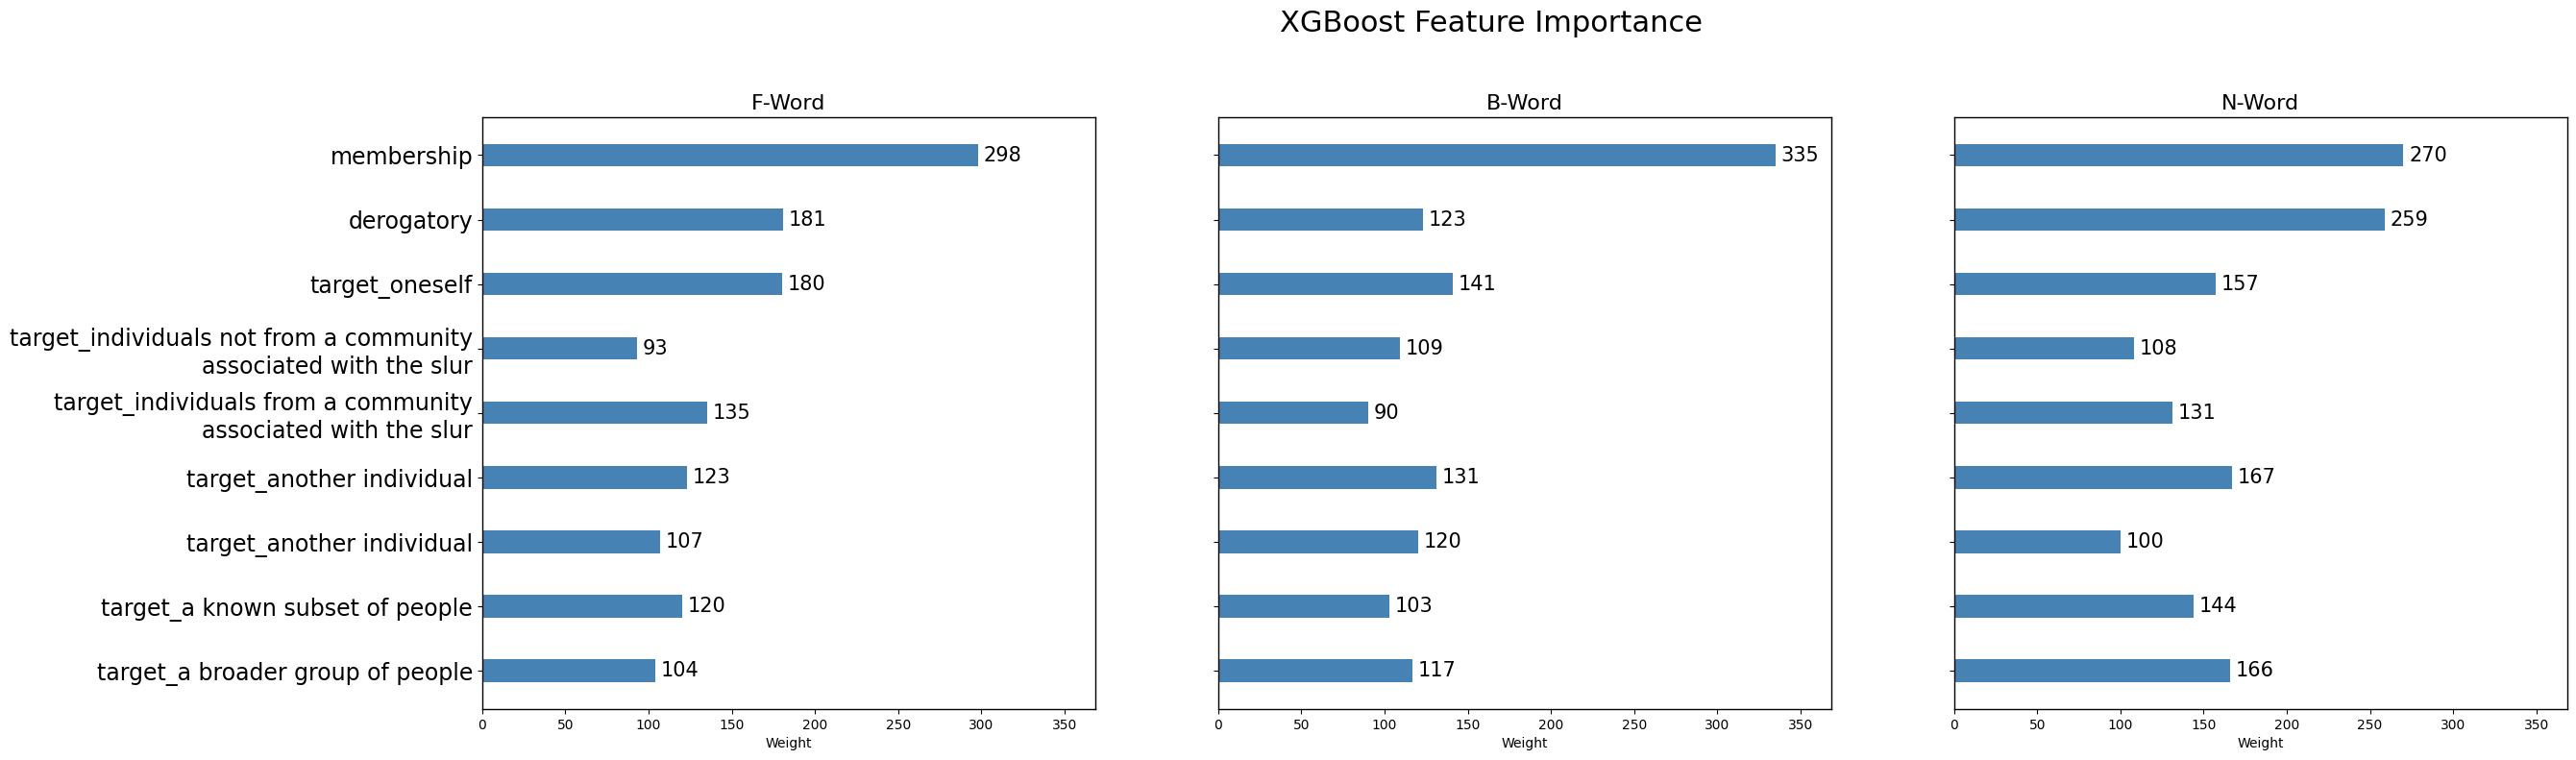

In [20]:
plot_xgBoost(f_word_df, n_word_df, b_word_df)

### Linear Mixed Effect Model (Appendix Table 5)

In [21]:

def linear_mixed_effects(original_df, word, print_summary=False):
  with open(f'../data/{word}-perspective_variation.csv', 'r') as f:
    variation = pd.read_csv(f, index_col=False)
    variation = variation.drop(columns=[variation.columns[0]])

  df = original_df.copy(deep=True)

  clean_cols = ['reclaim', 'context', 'derogatory', 'target']

  for col in clean_cols:
      df[col] = df[col].astype(str).str.strip().str.lower()
      df[col] = df[col].replace({"nan": "missing", "none": "missing", "" : "missing"})


  df["group_matter"] = (df["ingroup"] != df["outgroup"]).map({True: "yes", False: "no"})
  df["group_matter_binary"] = df["group_matter"].map({"yes": 1, "no": 0})

  df = df.reset_index(drop=True)
  df["annotator_id"] = df["annotator_id"].astype("category")
  df["text_id"] = df["text_id"].astype("category")

  for col in clean_cols:
    df[col] = df[col].astype("category")


  formula = 'group_matter_binary ~ C(reclaim, Treatment(reference="neither")) + C(context, Treatment(reference="discussion of identity")) + C(derogatory, Treatment(reference="no")) + C(target, Treatment(reference="another individual"))'
  model = smf.mixedlm(
      formula,
      df,
      groups=df["text_id"],                    # random intercept per tweet
      vc_formula={"annotator": "0 + annotator_id"}, # random effect per annotator
      missing='none'
  ).fit()

  if print_summary:
    print(model.summary())
  return model


In [22]:
def format_linear_mixed_effects(models):
  # Map statsmodels parameter names → LaTeX row labels
  label_map = {
      'C(reclaim, Treatment(reference="neither"))[T.insular]': "Insular",
      'C(reclaim, Treatment(reference="neither"))[T.pride]': "Pride",
      'C(reclaim, Treatment(reference="neither"))[T.missing]': "Missing (Reclaim)",

      'C(context, Treatment(reference="discussion of identity"))[T.counter speech]': "Counter speech",
      'C(context, Treatment(reference="discussion of identity"))[T.discussion of slur]': "Discussion of slur",
      'C(context, Treatment(reference="discussion of identity"))[T.missing]': "Missing (Context)",
      'C(context, Treatment(reference="discussion of identity"))[T.neologism]': "Neologism",
      'C(context, Treatment(reference="discussion of identity"))[T.quote]': "Quote",
      'C(context, Treatment(reference="discussion of identity"))[T.recollection]': "Recollection",
      'C(context, Treatment(reference="discussion of identity"))[T.sarcasm]': "Sarcasm",
      'C(context, Treatment(reference="discussion of identity"))[T.sexualization]': "Sexualization",

      'C(derogatory, Treatment(reference="no"))[T.yes]': "Derogatory (Yes)",
      'C(derogatory, Treatment(reference="no"))[T.missing]': "Missing (Derogatory)",

      'C(target, Treatment(reference="another individual"))[T.a broader group of people]': "A broader group of people",
      'C(target, Treatment(reference="another individual"))[T.a known subset of people]': "A known subset of people",
      'C(target, Treatment(reference="another individual"))[T.individuals from a community associated with the slur]': "Individuals from a community associated with the slur",
      'C(target, Treatment(reference="another individual"))[T.individuals not from a community associated with the slur]': "Individuals not from a community associated with the slur",
      'C(target, Treatment(reference="another individual"))[T.missing]': "Missing (Target)",
      'C(target, Treatment(reference="another individual"))[T.oneself]': "Oneself",
      'annotator Var': 'Annotator Variation',
      'Intercept': 'Intercept'

  }

  def sig_stars_from_p(p):
      if p < 0.01:
          return "***"
      elif p < 0.05:
          return "**"
      elif p < 0.10:
          return "*"
      else:
          return ""

  def fmt_cell(coef, ci_low, ci_high, p):
      stars = sig_stars_from_p(p)
      if stars:
          coef_part = f"{coef:.3f}$^{{{stars}}}$"
      else:
          coef_part = f"{coef:.3f}"
      return f"{coef_part} ({ci_low:.3f}, {ci_high:.3f})"

  slur_order = ['f-word', 'b-word', 'n-word']


  # Build LaTeX table rows
  for param_name, nice_label in label_map.items():
      cell_values = []

      for slur in slur_order:
          m = models[slur]

          if param_name in m.params.index:
              coef = m.params[param_name]
              ci_low, ci_high = m.conf_int().loc[param_name]
              p = m.pvalues[param_name]
              cell = fmt_cell(coef, ci_low, ci_high, p)
          else:
              cell = "---"

          cell_values.append(cell)

      latex_row = "\\hspace{3mm}" + nice_label + " & " + " & ".join(cell_values) + " \\\\"
      print(latex_row)

In [23]:
models = {}
models['f-word'] = linear_mixed_effects(f_word_df, 'f-word')
models['b-word'] = linear_mixed_effects(b_word_df, 'b-word')
models['n-word'] = linear_mixed_effects(n_word_df, 'n-word')

format_linear_mixed_effects(models)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not 

\hspace{3mm}Insular & 0.194$^{***}$ (0.120, 0.268) & 0.123$^{***}$ (0.060, 0.187) & 0.041 (-0.046, 0.127) \\
\hspace{3mm}Pride & 0.416$^{***}$ (0.278, 0.554) & 0.169$^{***}$ (0.075, 0.264) & 0.120$^{**}$ (0.011, 0.230) \\
\hspace{3mm}Missing (Reclaim) & -4336592310871269.000$^{***}$ (-4336592334122877.000, -4336592287619661.000) & 0.082 (-0.091, 0.255) & --- \\
\hspace{3mm}Counter speech & 0.031 (-0.149, 0.210) & -0.131 (-0.300, 0.038) & -0.107 (-0.324, 0.110) \\
\hspace{3mm}Discussion of slur & -0.148$^{**}$ (-0.280, -0.017) & -0.104 (-0.379, 0.170) & 0.232$^{***}$ (0.136, 0.329) \\
\hspace{3mm}Missing (Context) & 0.030 (-0.087, 0.148) & -0.115$^{**}$ (-0.214, -0.015) & 0.330$^{***}$ (0.137, 0.523) \\
\hspace{3mm}Neologism & 0.147$^{**}$ (0.017, 0.276) & -0.143$^{***}$ (-0.233, -0.052) & 0.501$^{***}$ (0.395, 0.607) \\
\hspace{3mm}Quote & -0.091 (-0.252, 0.069) & -0.138$^{**}$ (-0.275, -0.001) & 0.555$^{***}$ (0.439, 0.670) \\
\hspace{3mm}Recollection & -0.094 (-0.269, 0.081) & -0.036

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


### Context Heatmap (Figure 2)

In [24]:
def plot_heatmap(orginal_f_df, original_n_df, original_b_df, drop_nans=False):
    f_df = orginal_f_df.copy(deep=True)
    n_df = original_n_df.copy(deep=True)
    b_df = original_b_df.copy(deep=True)

    # --- Normalize context columns FIRST (prevents float/str comparison errors) ---
    for df in [f_df, n_df, b_df]:
        for col in ['context', 'context_sec']:
            df[col] = (
                df[col]
                .astype(str)                 # convert everything to string
                .replace('nan', 'missing')   # pandas NaN -> 'missing'
                .str.lower()                 # normalize casing
            )

    # Optionally drop rows where context is missing
    if drop_nans:
        for df in [f_df, n_df, b_df]:
            df.drop(df[df['context'] == 'missing'].index, inplace=True)

    # Ensure "missing" is always last
    context_label = sorted(
        f_df['context'].unique(),
        key=lambda x: (x == 'missing', x)
    )



    fig, axs = plt.subplots(
        2, 3,
        sharex=True,
        sharey='row',
        figsize=(25, 10),
        gridspec_kw={'height_ratios': [len(context_label), 1]}
    )

    sns.set(font_scale=1.3)

    title_map = {
        'f-word': 'F-Word',
        'b-word': 'B-Word',
        'n-word': 'N-Word'
    }

    cbar_ax_0 = fig.add_axes([.91, .35, .02, .4])
    cbar_ax_1 = fig.add_axes([.91, .1, .01, .1])

    for idx, (word, df) in enumerate([
        ('f-word', f_df),
        ('b-word', b_df),
        ('n-word', n_df)
    ]):

        # Cross-tabulate with controlled ordering
        frequency_counts = pd.crosstab(
            index=df['context_sec'],
            columns=df['context'],
            dropna=False
        ).reindex(
            index=context_label,
            columns=context_label,
            fill_value=0
        )

        heatmap = frequency_counts.values
        totals = heatmap.sum(axis=0, keepdims=True)

        # Create annotation arrays where 0s are blank
        heatmap_annot = np.where(heatmap == 0, "", heatmap.astype(str))
        totals_annot = np.where(totals == 0, "", totals.astype(str))

        # # Create annotation arrays where 0s are -
        # heatmap_annot = np.where(heatmap == 0, "-", heatmap.astype(str))
        # totals_annot = np.where(totals == 0, "-", totals.astype(str))

        # # Create annotation arrays where 0s are ·
        # heatmap_annot = np.where(heatmap == 0, "·", heatmap.astype(str))
        # totals_annot = np.where(totals == 0, "·", totals.astype(str))

        # heatmap_annot = heatmap.astype(str)
        # totals_annot = totals.astype(str)

        sns.heatmap(
            heatmap,
            annot=heatmap_annot,
            yticklabels=context_label,
            xticklabels=context_label,
            ax=axs[0][idx],
            cbar=idx == 0,
            vmin=0,
            vmax=100,
            cbar_ax=None if idx else cbar_ax_0,
            fmt=""
        )

        sns.heatmap(
            totals,
            annot=totals_annot,
            yticklabels=['total count'],
            xticklabels=context_label,
            ax=axs[1][idx],
            cbar=idx == 0,
            vmin=0,
            vmax=300,
            cbar_ax=None if idx else cbar_ax_1,
            fmt=""
        )

        axs[0][idx].set_ylabel('Secondary salient context', fontsize=16)
        axs[0][idx].set_aspect(1)
        axs[0][idx].set_title(title_map[word], fontsize=16)
        axs[0][idx].tick_params(axis='y', labelsize=14)

        axs[1][idx].set_xlabel('Primary salient context', fontsize=16)
        axs[1][idx].tick_params(axis='x', labelrotation=45, labelsize=14)
        axs[1][idx].tick_params(axis='y', labelsize=14)

    fig.suptitle(
        "Heatmap of P(Secondary salient context | Primary salient context)",
        fontsize=22
    )


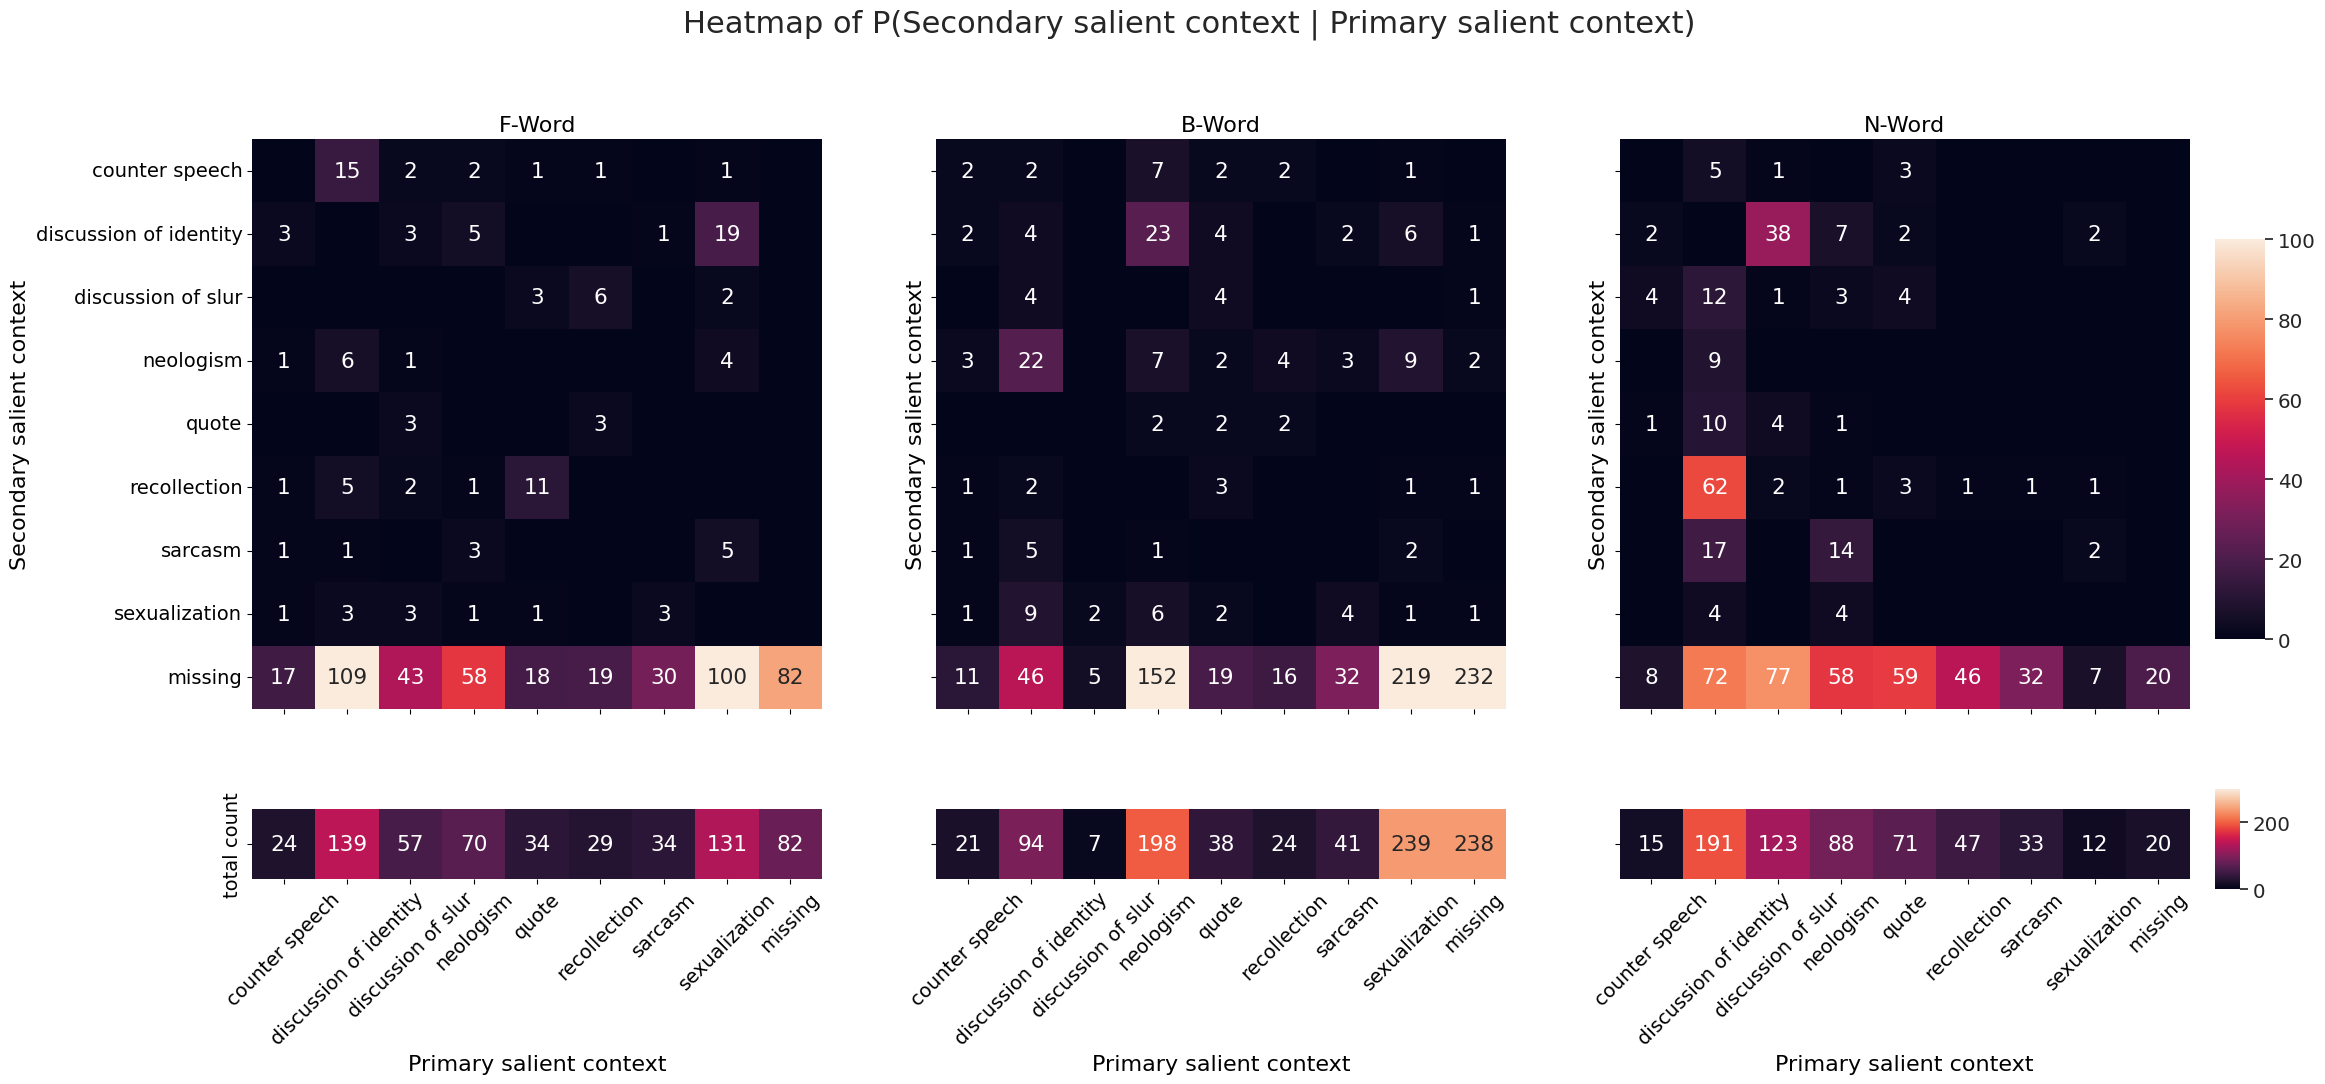

In [25]:
plot_heatmap(f_word_df, n_word_df, b_word_df, drop_nans=False)

## Model Calibration

### TV Distance

In [26]:
def tv_distance(actual, probs, mean=False):
    actual = np.asarray(actual, dtype=float)
    probs = np.asarray(probs, dtype=float)

    mask = ~np.isnan(actual) & ~np.isnan(probs)
    actual = actual[mask]
    probs = probs[mask]

    assert(len(actual) == len(probs))

    if len(actual) == 0:
        return np.nan

    if mean:
        return np.mean(np.abs(actual - probs))
    else:
        return np.abs(actual - probs)

In [27]:
f_text_df.columns

Index(['text_id', 'text', 'perspective_api_identity_attack', 'ingroup',
       'outgroup', 'ingroup_nan', 'outgroup_nan', 'ingroup_p', 'outgroup_p',
       'ingroup_majority', 'outgroup_majority', 'ingroup_at_least_one',
       'outgroup_at_least_one'],
      dtype='object')

### Voting Method TV Distance (Appendix Table 6)

In [28]:
def get_voting_method(orginal_df):
  df = orginal_df.copy(deep=True)
  in_majority = tv_distance(df.ingroup_p, df.ingroup_majority, mean=True)
  in_at_least = tv_distance(df.ingroup_p, df.ingroup_at_least_one, mean=True)
  out_majority = tv_distance(df.outgroup_p, df.outgroup_majority, mean=True)
  out_at_least = tv_distance(df.outgroup_p, df.outgroup_at_least_one, mean=True)

  print("At Least One")
  print(f'Out Group: {out_at_least}')
  print(f'In Group: {in_at_least}')

  print("Majority")
  print(f'Out Group: {out_majority}')
  print(f'In Group: {in_majority}')
  print('\n')


In [29]:
print('F-Word')
get_voting_method(f_text_df)
print('N-Word')
get_voting_method(n_text_df)
print('B-Word')
get_voting_method(b_text_df)

F-Word
At Least One
Out Group: 0.31166666666666665
In Group: 0.45500000000000007
Majority
Out Group: 0.23833333333333329
In Group: 0.225


N-Word
At Least One
Out Group: 0.4583333333333334
In Group: 0.45833333333333337
Majority
Out Group: 0.37833333333333335
In Group: 0.185


B-Word
At Least One
Out Group: 0.45666666666666667
In Group: 0.5822222222222222
Majority
Out Group: 0.2766666666666667
In Group: 0.2677777777777778




### Distributional Alignment (Appendix Figure 4)

In [30]:
def plot_alignment(orginal_f_df, original_n_df, original_b_df):
  f_t_df = f_text_df.copy(deep=True)
  n_t_df = n_text_df.copy(deep=True)
  b_t_df = b_text_df.copy(deep=True)

  # fig, axs = plt.subplots(2, 3, sharex=True, sharey='row', figsize=(25, 10))
  fig, axs = plt.subplots(2, 3, sharex=True, sharey='row', figsize=(35, 15))
  fig.subplots_adjust(wspace=0.1, hspace=0.2)
  title_map = {
      'f-word': 'F-Word',
      'b-word': 'B-Word',
      'n-word': 'N-Word'
  }


  for idx, (word, text_df) in enumerate([('f-word', f_t_df), ('b-word', b_t_df), ('n-word', n_t_df)]):

    plot_df = pd.DataFrame(data={"P(hate | ingroup)": text_df.ingroup_p, "P(hate | outgroup)": text_df.outgroup_p, "P(identity attack), Perspective API": text_df.perspective_api_identity_attack})
    sns.kdeplot(plot_df, ax=axs[0][idx], legend=True)
    sns.histplot(plot_df, ax=axs[1][idx], multiple="dodge", alpha=0.5, legend=True, edgecolor="black")

    if idx == 0:
      axs[0][idx].set_ylabel(ylabel="Density", fontsize=18)
      axs[1][idx].set_ylabel(ylabel="Count", fontsize=18)

    fig.suptitle("Comparison of Human Annotations of Group-based Reporting vs. Perspective API Output", fontsize=24, y=0.96)
    sns.set_style("white")

    axs[0][idx].set_title(f"{title_map[word]}", fontsize=18)
    axs[1][idx].set_xlabel("Probability", fontsize=18)
    for ax in axs.flat:
      ax.grid(False)
      ax.tick_params(
        which='both',
        bottom=True, top=False,
        left=True, right=False,
        labelsize=14
      )
    handles, labels = axs[0][idx].get_legend_handles_labels()
    if handles:
        axs[0][idx].legend(handles=handles, labels=labels, fontsize=12)

    handles, labels = axs[1][idx].get_legend_handles_labels()
    if handles:
        axs[1][idx].legend(handles=handles, labels=labels, fontsize=12)


In [31]:
def plot_alignment_count(orginal_f_df, original_n_df, original_b_df):
  f_t_df = f_text_df.copy(deep=True)
  n_t_df = n_text_df.copy(deep=True)
  b_t_df = b_text_df.copy(deep=True)

  # fig, axs = plt.subplots(2, 3, sharex=True, sharey='row', figsize=(25, 10))
  # fig, axs = plt.subplots(2, 3, sharex=True, sharey='row', figsize=(35, 15))
  fig, axs = plt.subplots(1, 3, figsize=(28, 8), sharey=True)
  fig.subplots_adjust(wspace=0.1, hspace=0.2)
  title_map = {
      'f-word': 'F-Word',
      'b-word': 'B-Word',
      'n-word': 'N-Word'
  }


  for idx, (word, text_df) in enumerate([('f-word', f_t_df), ('b-word', b_t_df), ('n-word', n_t_df)]):

    plot_df = pd.DataFrame(data={"P(hate | ingroup)": text_df.ingroup_p, "P(hate | outgroup)": text_df.outgroup_p, "P(identity attack), Perspective API": text_df.perspective_api_identity_attack})
    sns.histplot(plot_df, ax=axs[idx], multiple="dodge", alpha=0.5, legend=True, edgecolor="black")


    axs[idx].set_ylabel(ylabel="Count", fontsize=18)

    fig.suptitle("Comparison of Human Annotations of Group-based Reporting vs. Perspective API Output", fontsize=22, y=1.0)
    sns.set_style("white")

    axs[idx].set_title(f"{title_map[word]}", fontsize=18)
    axs[idx].set_xlabel("Probability", fontsize=18)
    for ax in axs.flat:
      ax.grid(False)
      ax.tick_params(
        which='both',
        bottom=True, top=False,
        left=True, right=False,
        labelsize=14
      )
    handles, labels = axs[idx].get_legend_handles_labels()
    if handles:
        axs[idx].legend(handles=handles, labels=labels, fontsize=12)

    handles, labels = axs[idx].get_legend_handles_labels()
    if handles:
        axs[idx].legend(handles=handles, labels=labels, fontsize=12)


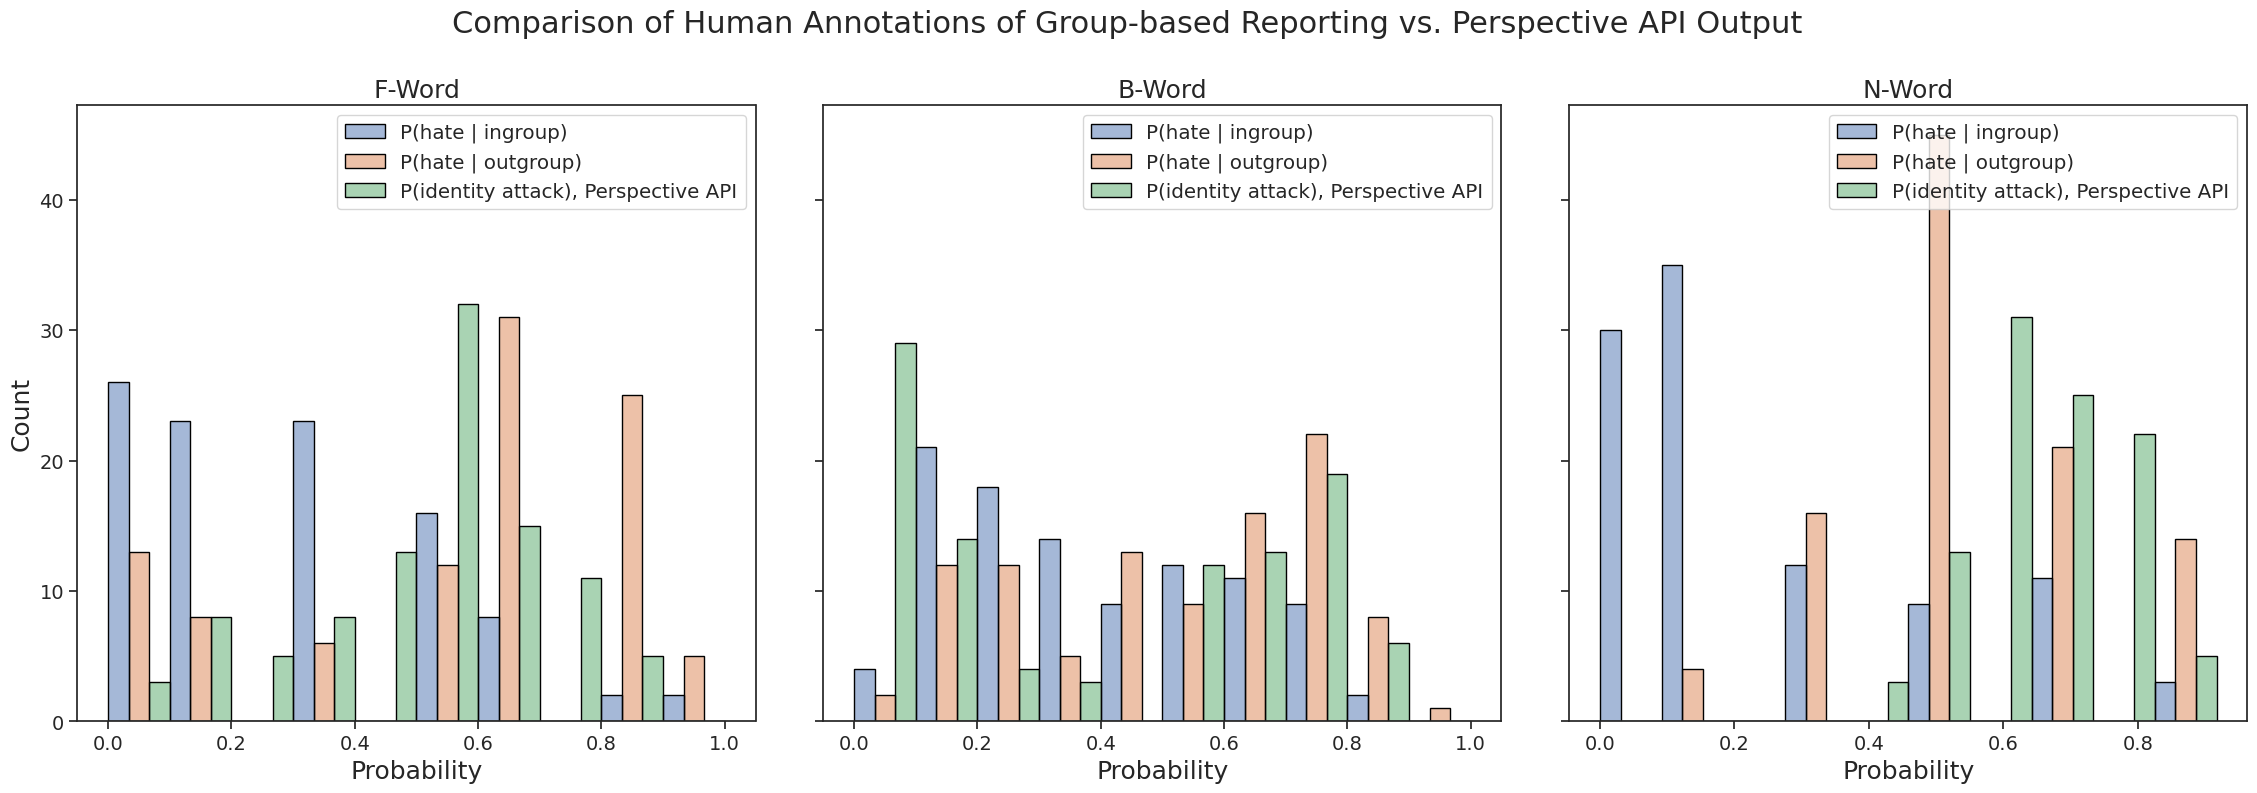

In [38]:
plot_alignment_count(f_word_df, n_word_df, b_word_df)

### Calculating Average Total Variation and Text-wise Variation (Table 2)

In [33]:
f_text_df.columns

Index(['text_id', 'text', 'perspective_api_identity_attack', 'ingroup',
       'outgroup', 'ingroup_nan', 'outgroup_nan', 'ingroup_p', 'outgroup_p',
       'ingroup_majority', 'outgroup_majority', 'ingroup_at_least_one',
       'outgroup_at_least_one'],
      dtype='object')

In [34]:
# average total variation over all examples by ingroup vs outgroup
print(f"ATV ingroup over all examples: {tv_distance([df.ingroup_p for df in [f_text_df, n_text_df, b_text_df]], \
                                                    [df.perspective_api_identity_attack for df in [f_text_df, n_text_df, b_text_df]], \
                                                    mean=True)}")
print(f"ATV outgroup over all examples: {tv_distance([df.outgroup_p for df in [f_text_df, n_text_df, b_text_df]], \
                                                     [df.perspective_api_identity_attack for df in [f_text_df, n_text_df, b_text_df]], \
                                                     mean=True)}")

# average total variation over each word, and then within that the ingroup vs outgroup
for word, df in [('f-word', f_text_df), ('n-word', n_text_df), ('b-word', b_text_df)]:
  print(f"ATV ingroup for {word}: {tv_distance(df.ingroup_p, df.perspective_api_identity_attack, mean=True)}")
  print(f"ATV outgroup for {word}: {tv_distance(df.outgroup_p, df.perspective_api_identity_attack, mean=True)}")

ATV ingroup over all examples: 0.3011101380520253
ATV outgroup over all examples: 0.2229157504845782
ATV ingroup for f-word: 0.30485862358666665
ATV outgroup for f-word: 0.30063500848
ATV ingroup for n-word: 0.42031270400673393
ATV outgroup for n-word: 0.13981428124579126
ATV ingroup for b-word: 0.17935111222222222
ATV outgroup for b-word: 0.2274669470355556


### Top n Largest Delta for TV (Table 3)

In [51]:
def print_top_examples(word_df,  n=3):
  df = word_df.dropna(subset=['perspective_api_identity_attack', 'ingroup_p', 'outgroup_p']).copy()
  df['delta-ingroup'] = tv_distance(word_df.ingroup_p, word_df.perspective_api_identity_attack)
  df['delta-outgroup'] = tv_distance(word_df.outgroup_p, word_df.perspective_api_identity_attack)

  print(f"Top {n} delta for ingroup:")
  display(df.sort_values(by='delta-ingroup', ascending=False)[['text_id', 'text', 'delta-ingroup']].head(3))
  print(f"Top {n} delta for outgroup:")
  display(df.sort_values(by='delta-outgroup', ascending=False)[['text_id', 'text', 'delta-outgroup']].head(3))

In [52]:
for word, df in [('f-word', f_text_df), ('n-word', n_text_df), ('b-word', b_text_df)]:
  print(f"Printing results for {word}")
  print_top_examples(df)
  print()


Printing results for f-word
Top 3 delta for ingroup:


,text_id,text,delta-ingroup
96,1819366352785658112$twitter,@[MASK] @[MASK] Gay gay faggy gay gay gay quee...,0.720781
25,1819387625301541120$twitter,Smoking 20 fags at once is insanity,0.697837
94,acl23860$dynahate,"""Durr nigger. Durrr tranny. Durr fag. Durr cun...",0.622924


Top 3 delta for outgroup:


,text_id,text,delta-outgroup
1,1819346988548178176$twitter,RT @[MASK]: Muscle f*gs are prone to rough pou...,0.933413
33,1819386094758109184$twitter,@[MASK] Shut up F*g bag,0.897784
7,1819379437449666816$twitter,@[MASK] Ron Paul is based. Why are you all bei...,0.788978



Printing results for n-word
Top 3 delta for ingroup:


...

,text_id,text,delta-outgroup
67,acl23987$dynahate,i hate being called a nigga,0.498255
63,acl24314$dynahate,Are you able to picture being able to get non-...,0.383869
26,acl12399$dynahate,I dont accept people calling my friend n*gga,0.383781



Printing results for b-word
Top 3 delta for ingroup:


,text_id,text,delta-ingroup
85,acl34706$dynahate,Black baby ain't really gonna be great. And th...,0.629551
64,acl5128$dynahate,I'm a big black bitch and I love it!,0.550447
7,1819390953326571776$twitter,@[MASK] @[MASK] @[MASK] Better not see you bit...,0.542261


Top 3 delta for outgroup:


,text_id,text,delta-outgroup
30,1819391000806060544$twitter,"@[MASK] @[MASK] @[MASK] Bitch, you haven't pla...",0.727789
10,acl32640$dynahate,actually texting her 20 times a day is still n...,0.715283
13,acl34604$dynahate,I find it hilarious how she suddenly sees hers...,0.711966


### Perspective API and Annotation Alignment (Figure 3)

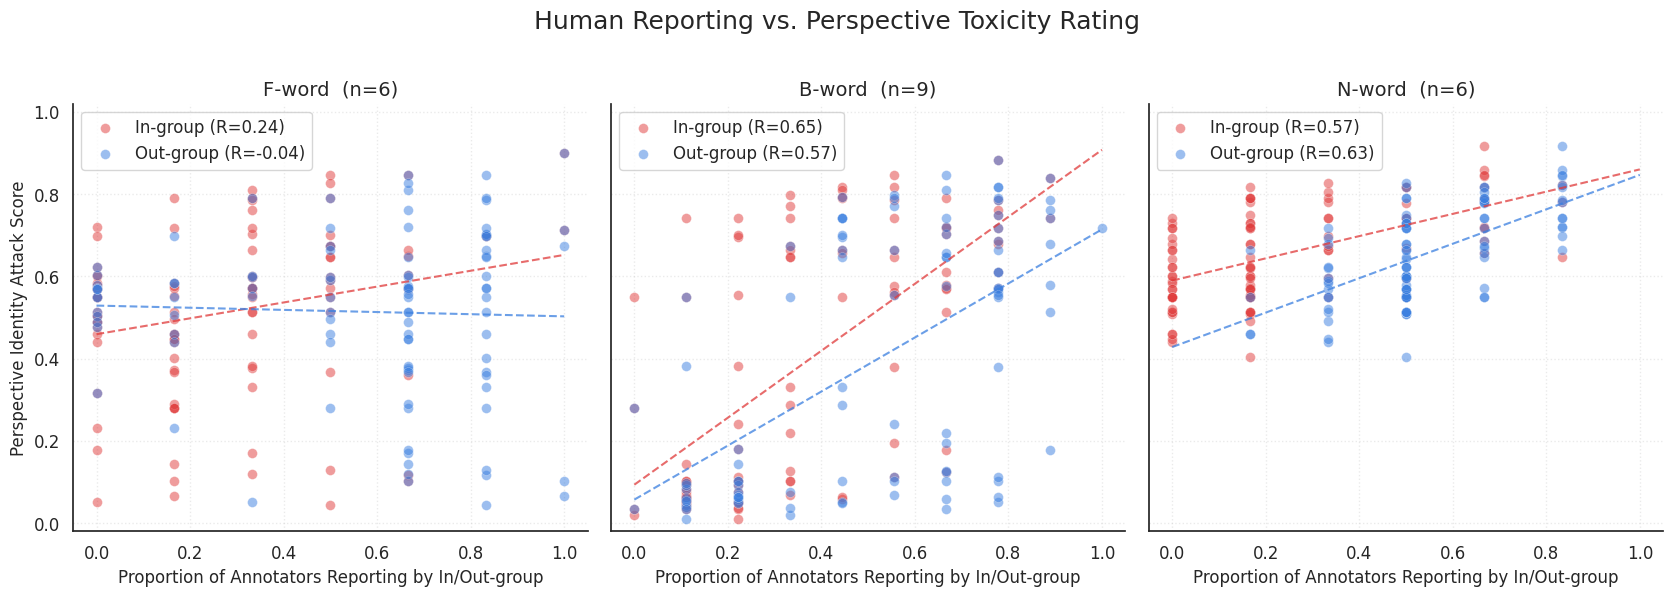

In [37]:
def compute_yes_pct(annotator_df, text_df, word_label):
    ann = annotator_df.copy(deep=True)
    txt = text_df.copy(deep=True)

    agg = (
        ann
        .groupby('text_id')[['ingroup', 'outgroup']]
        .apply(lambda g: g.eq('yes').mean())
        .reset_index()
    )
    agg.columns = ['text_id', 'ingroup_pct', 'outgroup_pct']

    merged = agg.merge(
        txt[['text_id', 'perspective_api_identity_attack']],
        on='text_id', how='inner'
    )
    merged['word'] = word_label
    return merged


# --- Build combined df ---
dfs = [
    compute_yes_pct(f_word_df, f_text_df, 'f-word'),
    compute_yes_pct(b_word_df, b_text_df, 'b-word'),
    compute_yes_pct(n_word_df, n_text_df, 'n-word'),
]
combined = pd.concat(dfs, ignore_index=True)

INGROUP_COLOR  = '#E03A3A'
OUTGROUP_COLOR = '#3A7FE0'
JITTER_STR = 2.5  # tweak to taste



slur_cfg = [
    ('f-word', 'F-word', f_word_df),
    ('b-word', 'B-word', b_word_df),
    ('n-word', 'N-word', n_word_df),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)
fig.suptitle(
    'Human Reporting vs. Perspective Toxicity Rating',
    fontsize=18, y=1.0
)

for ax, (word_key, word_title, ann_df) in zip(axes, slur_cfg):
    grp = combined[combined['word'] == word_key]
    n   = len(grp)
    n_annotators = ann_df['annotator_id'].nunique()
    # jitter_str   = (1 / n_annotators) * 0.2
    jitter_str = 0

    for x_col, label, color in [
        ('ingroup_pct',  'In-group',  INGROUP_COLOR),
        ('outgroup_pct', 'Out-group', OUTGROUP_COLOR),
    ]:
        x_jittered = grp[x_col] + np.random.uniform(-jitter_str, jitter_str, size=n)

        x_vals = grp[x_col].values
        y_vals = grp['perspective_api_identity_attack'].values
        mask   = ~np.isnan(x_vals) & ~np.isnan(y_vals)

        # Compute R²
        if mask.sum() > 1:
            r_value, _ = stats.pearsonr(x_vals[mask], y_vals[mask])
            # _, _, r_value, _, _ = stats.linregress(x_vals[mask], y_vals[mask])
            # r2 = r_value ** 2
            r2 = r_value
            # legend_label = f'{label} (R²={r2:.2f})'
            legend_label = f'{label} (R={r2:.2f})'
        else:
            legend_label = label

        ax.scatter(
            x_jittered,
            grp['perspective_api_identity_attack'],
            c=color,
            label=legend_label,
            alpha=0.5,
            edgecolors='white',
            linewidths=0.3,
            s=50,
        )

        if mask.sum() > 1:
            m, b = np.polyfit(x_vals[mask], y_vals[mask], 1)
            x_line = np.linspace(0, 1, 200)
            ax.plot(x_line, m * x_line + b,
                    color=color, linewidth=1.5, linestyle='--', alpha=0.75)

    ax.set_title(f'{word_title}  (n={n_annotators})', fontsize=14)
    ax.set_xlabel('Proportion of Annotators Reporting by In/Out-group', fontsize=12)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=12, frameon=True)
    ax.tick_params(axis='both', labelsize=12)



axes[0].set_ylabel('Perspective Identity Attack Score', fontsize=12)

plt.tight_layout()
plt.savefig('perspective_vs_agreement.png', dpi=150, bbox_inches='tight')
plt.show()